# [LAB-10] 4-2. 분류 성능 평가지표

## #01. 준비작업

### 1. 패키지 참조

In [3]:
# 라이브러리 기본 참조
from jussam import load_data
from helper import *
from pandas import DataFrame

import numpy as np

# 분류 성능 평가를 위한 참조
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 + 분류모델 적합

직전 단원과 동일한 데이터에 대해 전처리가 완료된 데이터를 준비한다.

In [4]:
origin = load_data('pima_indians_diabetes_preprocessed')
fit = my_logit.auto_logit(origin, 'Outcome', plot=False, report=False)

📚 피마 인디언 당뇨병 데이터셋에 대한 전처리 버전 - 결측치 처리, 이상치 처리, 라벨링 (출처: 자체 작업)



## 3. 혼동행렬 지표 얻기

In [6]:
y_true = np.asarray(fit.model.endog).astype(int)   # 실제 당뇨 여부(0/1)
proba = np.asarray(fit.predict())                  # 당뇨(1)일 예측 확률
y_pred = (proba > 0.5).astype(int)                 # 임계값 0.5로 이진화
cm = confusion_matrix(y_true, y_pred)              # 혼동행렬 배열

# 네 칸을 TN / FP / FN / TP 로 분해 (순서가 정해져 있다)
tn, fp, fn, tp = cm.ravel()

print(f"TN(정상인을 정상으로 맞힘) : {tn}")
print(f"FP(정상인을 당뇨로 헛짚음) : {fp}")
print(f"FN(당뇨 환자를 놓침)       : {fn}")
print(f"TP(당뇨 환자를 맞힘)       : {tp}")

TN(정상인을 정상으로 맞힘) : 420
FP(정상인을 당뇨로 헛짚음) : 55
FN(당뇨 환자를 놓침)       : 107
TP(당뇨 환자를 맞힘)       : 142


## #02. 정확도(Accuracy)

### 1. 직접 구하기

- **정확도**는 전체 중에서 **맞게 분류한 비율**이다.
- 성적표로 치면 "100문제 중 몇 개 맞았나"에 해당한다. 가장 먼저 떠오르는 지표다.
- 혼동행렬에서는 **맞힌 칸(TN·TP)을 전부 더해 전체로 나눈다.**

$$ Accuracy = \frac{\text{정확히 예측한 수}}{\text{전체 수}} = \frac{TN+TP}{TN+FP+FN+TP} $$

In [8]:
ac = accuracy_score(y_true, y_pred)
ac

0.7762430939226519

### 2. 함수로 구하기

- `sklearn`의 함수를 사용하면 같은 값을 한 줄로 얻을 수 있다.

In [9]:
(tn + tp) / (tn + fp + fn + tp)

np.float64(0.7762430939226519)

#### 인사이트

- **정확도 0.776** — 724명 중 562명을 맞혔다. 직접 계산과 함수 계산이 같은 값이다.
- 숫자만 보면 "열 명 중 여덟 명은 맞힌다"는 뜻이라 꽤 쓸 만한 모형처럼 보인다.
- 그런데 **이 숫자 하나만 믿어도 될까?** 바로 아래에서 확인한다.

### 3. 정확도의 함정 (1) - 정답의 구성 비율 확인

- 우리 데이터에 당뇨(1)와 정상(0)이 각각 몇 명인지 센다.

In [10]:
# 종속변수의 값별 개수
count = origin["Outcome"].value_counts()

# 종속변수의 값별 비율
ratio = origin["Outcome"].value_counts(normalize=True)

DataFrame({"인원수" : count, "비율" : ratio})

,인원수,비율
Outcome,,
0,475,0.656
1,249,0.344


#### 인사이트

- 정상(0) **475명(65.6%)**, 당뇨(1) **249명(34.4%)** 로 **한쪽이 두 배 가까이 많다.**
- 이렇게 한쪽으로 치우친 데이터를 **불균형 데이터**라고 한다. 실무 데이터는 대부분 불균형이다.
- 여기서 **"무조건 정상이라고만 답하는"** 게으른 모형을 만들면 정확도가 얼마나 나올까?

### 4. 정확도의 함정 (2) - 무조건 정상(0)이라고만 답하는 게으른 모형의 정확도

In [12]:
# 아무 것도 계산하지 않고 무조건 '정상(0)'이라고만 답하는 모형
# --> 실제 정답의 길이만큼 0으로 채워진 배열을 만들어서 평가
y_lazy = np.zeros(len(y_true), dtype=int)

# 실제 정답과 모든 예측값이 0으로 채워진 배열에 대해 정확도 산출
lazy_acc = accuracy_score(y_true, y_lazy)
print(f"'무조건 정상' 모형의 정확도 : {lazy_acc:.1%}")

'무조건 정상' 모형의 정확도 : 65.6%


#### 인사이트

- 아무 것도 계산하지 않았는데 **정확도 65.6%** 가 나왔다. 정상인이 원래 그만큼 많기 때문이다.
- 만약 유병률이 1%인 희귀질환 이었다면 같은 방식으로 **정확도 99%** 가 나온다.
- 더 큰 문제는 이 게으른 모형이 **당뇨 환자 249명을 단 한 명도 찾지 못한다**는 점이다. 즉 **FN이 249명**이다.
- 우리가 **실습한 모형의 정확도는 77.6%** 이고, **FN(놓친 환자 수)는 107명**이다.
- **정확도 차이는 12%밖에 나지 않지만 FN은 거의 50% 정도 차이가 난다.**
- 정확도 숫자만 보면 훌륭한 모형으로 착각할 수 있다.


## #03. 정밀도(Precision)와 재현율(Recall)

### 1. 직접 구하기

- **정밀도**: *"당뇨라고 예측한 사람 중 진짜 당뇨의 비율"*
  - **헛짚음(FP)이 적을수록** 높아진다.
  - $\dfrac{TP}{TP+FP}$

- **재현율**: *"실제 당뇨 환자 중 모형이 찾아낸 비율"*
  - **놓침(FN)이 적을수록** 높아진다. 민감도(Sensitivity), TPR이라고도 부른다.
  - $\dfrac{TP}{TP+FN}$

In [14]:
pre = tp / (tn+fp)
recall = tp / (tp+fn)
print(f"정밀도(Precision) = TP/(TP+FP) = {pre:.4f}")
print(f"재현율(Recall)    = TP/(TP+FN) = {recall:.4f}")

정밀도(Precision) = TP/(TP+FP) = 0.2989
재현율(Recall)    = TP/(TP+FN) = 0.5703


### 3. 함수로 구하기

In [18]:
# 직접 계산과 함수 계산이 같은지 확인
pre = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"정밀도(Precision) = {pre:.4f}")
print(f"재현율(Recall)    = {recall:.4f}")

정밀도(Precision) = 0.7208
재현율(Recall)    = 0.5703


## #04. 위양성률(Fallout, FPR)과 특이성(Specificity, TNR)

### 1. 직접 계산하기

- 앞의 두 지표가 **양성(당뇨)** 기준이었다면, 이번 둘은 **음성(정상)** 기준이다.
  - 분모가 모두 **실제 정상인 수(TN + FP)** 로 같다.
- **위양성률(FPR)** = $\dfrac{FP}{TN+FP}$
  - *"멀쩡한 사람 중 당뇨라고 잘못 부른 비율"*
- **특이성(TNR)** = $\dfrac{TN}{TN+FP} = 1 - FPR$
  - *"멀쩡한 사람 중 제대로 걸러낸 비율"*

> 이 두 지표는 `sklearn`에 전용 함수가 없다. 혼동행렬 값으로 직접 계산한다.

In [19]:
fpr = fp / (fp+tn)        # 위양성률
tnr = 1 - fpr        # 특이성

print(f"위양성률(FPR) = FP/(FP+TN) = {fp}/{fp+tn} = {fpr:.4f}")
print(f"특이성(TNR)   = TN/(TN+FP) = {tn}/{tn+fp} = {tnr:.4f}")

위양성률(FPR) = FP/(FP+TN) = 55/475 = 0.1158
특이성(TNR)   = TN/(TN+FP) = 420/475 = 0.8842


#### 인사이트

- **특이성 0.88** — 정상인은 잘 걸러낸다. 반대로 **재현율은 0.57**로 환자를 잘 못 찾는다.
- 이런 불균형은 우연이 아니다. 모형이 **다수인 정상(65.6%) 쪽으로 기울어** 판단하기 때문이다.
- 임계값 0.5는 **다수 쪽에 유리한 기준**이라는 점을 기억해 두자.

## #05. F1 점수

### 1. 직접 계산

- 정밀도와 재현율은 한쪽을 올리면 다른 쪽이 내려간다. 그래서 **둘을 하나로 묶은 점수**가 필요하다.
- **F1 점수**는 정밀도와 재현율의 **조화평균**이다.
  - 한쪽이 0에 가까우면 **F1도 0에 가까워진다.**
  - 즉 **한쪽만 잘해서는 점수를 딸 수 없다.** 두 지표가 고르게 높아야 한다.
- 식에 **TN이 들어가지 않는다.** 그래서 불균형 데이터에서 정확도보다 신뢰할 만하다.

$$ F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall} = \frac{2TP}{2TP+FP+FN} $$


In [20]:
f1 = (2*tp) / (2* tp + fp + fn)
print(f"직접 계산 : {f1:.4f}")

직접 계산 : 0.6368


### 2. 함수 계산

In [21]:
f1 = f1_score(y_true, y_pred)
print(f"함수 계산 : {f1:.4f}")

함수 계산 : 0.6368


## #06. ROC 곡선과 AUC

### 1. 임계값에 따른 지표 변화 실험

In [24]:
rows=[]

for i in [0.3, 0.4, 0.5, 0.6, 0.7]: # 임계값을 0.3 ~ 0.7로 바꿔가며 관찰
    p = (proba > i).astype(int)     # 임계값 i로 이진화
    rows.append({
        "임계값" : i,
        "정확도" : accuracy_score(y_true, p),
        "정밀도" : precision_score(y_true, p),
        "재현율" : recall_score(y_true, p),
        "F1"     : f1_score(y_true, p),
        "놓친 환자수(FN)" : confusion_matrix(y_true, p).ravel()[2],
    })

display(DataFrame(rows).round(3))

,임계값,정확도,정밀도,재현율,F1,놓친 환자수(FN)
0,0.300,0.749,0.604,0.783,0.682,54
1,0.400,0.769,0.665,0.663,0.664,84
2,0.500,0.776,0.721,0.570,0.637,107
3,0.600,0.782,0.783,0.506,0.615,123
4,0.700,0.754,0.803,0.378,0.514,155


#### 인사이트

- **정밀도와 재현율이 정확히 반대로 움직인다.** 이것을 **트레이드오프**라고 한다.
  - 임계값 **0.3** → 재현율 **0.783**으로 치솟지만 정밀도는 **0.604**로 떨어진다.
  - 임계값 **0.7** → 정밀도 **0.803**으로 오르지만 재현율은 **0.378**로 반토막 난다.
- **놓친 환자 수(FN)** 를 보면 체감이 확실하다. 임계값 0.3에서 54명, 0.7에서는 155명을 놓친다.
- 정확도만 보면 **0.6이 최고(0.782)** 다. 하지만 그때 놓친 환자는 **123명**이다.
- **정답은 목적이 정한다.**
  - 당뇨 **검진**이라면 놓침이 치명적이므로 임계값을 **낮춰 재현율을 올리는 편**이 낫다.
  - 값비싼 정밀검사로 넘길 대상을 고르는 상황이라면 임계값을 **높여 정밀도를 올린다.**

### 2. 임계값에 따른 FPR・TPR 좌표 얻기

- `roc_curve()`는 임계값별 **FPR·TPR 좌표**를 한꺼번에 계산해 준다.
- 첫 줄의 임계값 `inf`는 **아무도 양성으로 판정하지 않는 상태**(곡선의 시작점 0,0)를 뜻한다.

In [26]:
roc_fpr, roc_tpr, thresholds = roc_curve(y_true, proba)

print(f"계산된 임계값 개수 : {len(thresholds)}개")
df = DataFrame({"임계값": thresholds, "FPR": roc_fpr, "TPR(재현율)": roc_tpr})
df.head(10)

계산된 임계값 개수 : 227개


,임계값,FPR,TPR(재현율)
0,inf,0.000,0.000
1,0.992,0.000,0.004
2,0.981,0.002,0.004
3,0.967,0.002,0.012
4,0.962,0.004,0.012
5,0.940,0.004,0.036
6,0.940,0.006,0.036
7,0.937,0.006,0.044
8,0.934,0.008,0.044
9,0.898,0.008,0.092


### 3. ROC 곡선 시각화

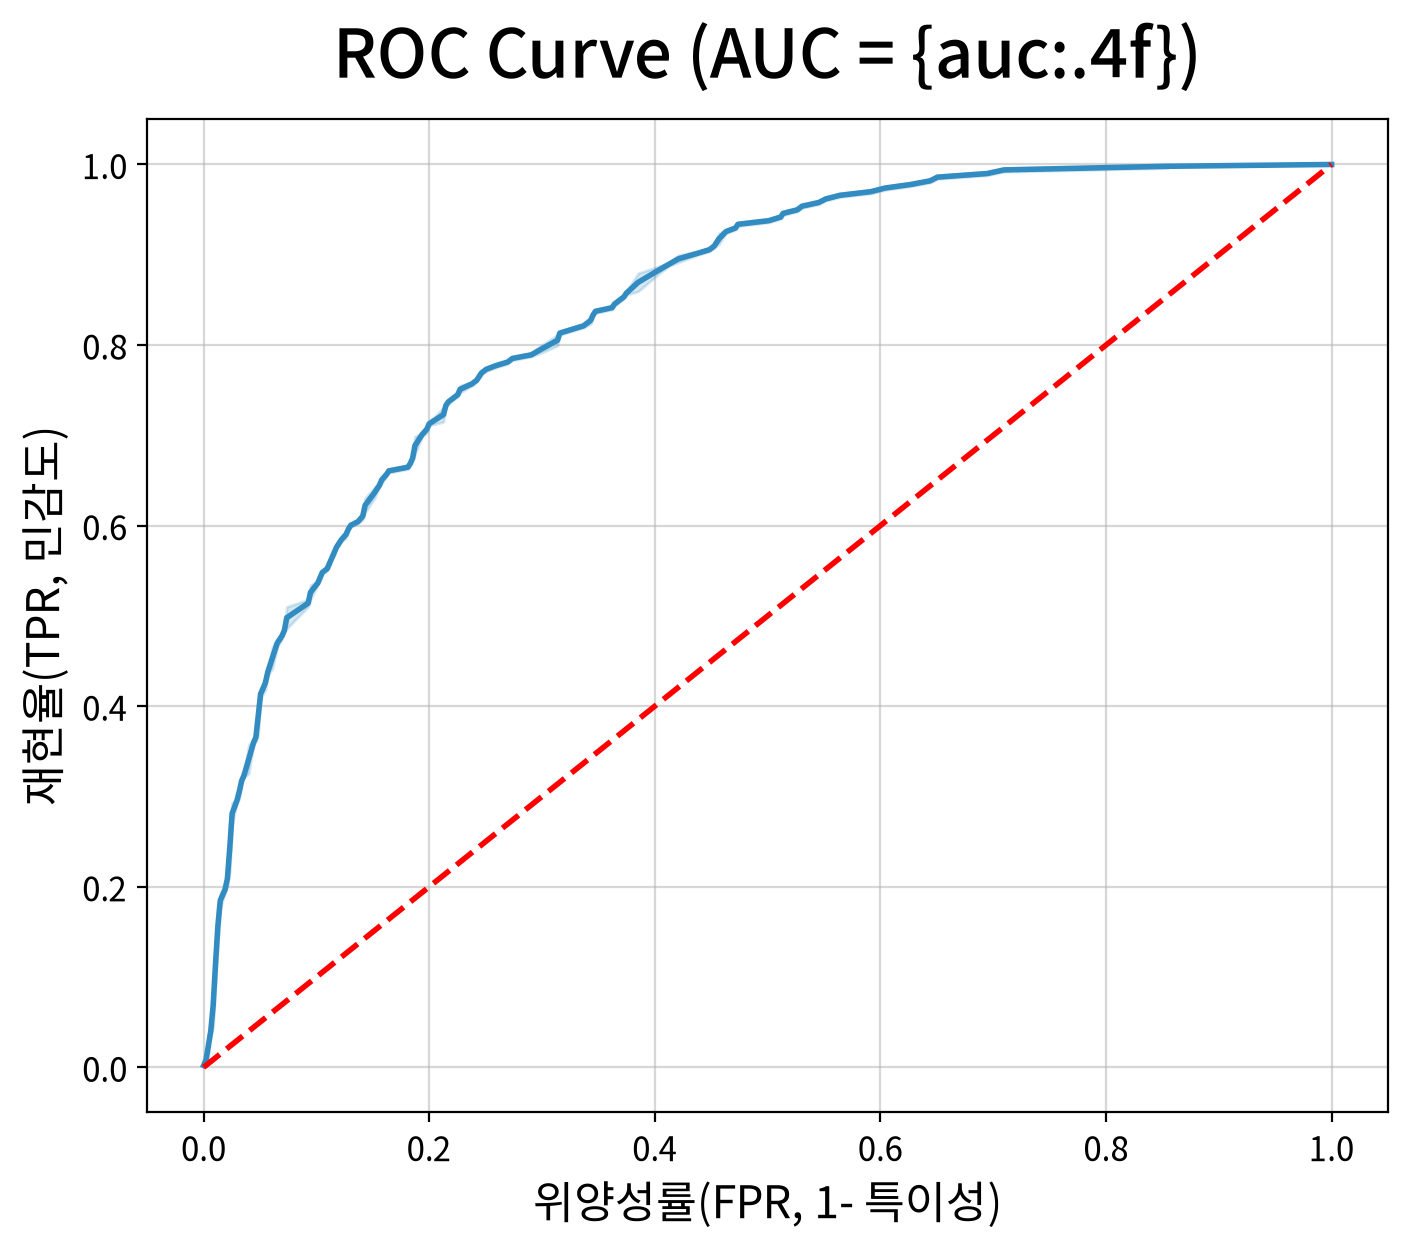

In [27]:
# ROC 곡선 아래 면적(AUC, Area Under Curve) 계산
auc = roc_auc_score(y_true, proba)

# 그래프 초기화
fig, ax = my_plot.init(width=720, height=640,
                       title="ROC Curve (AUC = {auc:.4f})",
                        xlabel="위양성률(FPR, 1- 특이성)",
                        ylabel="재현율(TPR, 민감도)")
                       
# ROC 곡선
my_plot.lineplot(x=roc_fpr, y=roc_tpr, color="#328cc1", ax=ax)

# 무작위로 찍었을 때의 기준선(대각선)
my_plot.lineplot(x=[0, 1], y=[0, 1], color="red", linestyle="--", ax=ax)

# 그래프 표시
my_plot.show()

#### 인사이트

- **AUC = 0.843**. **"우수"** 구간이다. 정확도 0.776, 재현율 0.570보다 훨씬 후한 점수다.
- 왜 차이가 날까?
  - 정확도·재현율은 **임계값 0.5 한 지점**의 성적이다.
  - AUC는 **모든 임계값**을 통틀어 본 성적이다.
- 해석하면 이렇다. **당뇨 환자 한 명과 정상인 한 명을 무작위로 뽑았을 때, 모형이 환자에게 더 높은 확률을 줄 가능성이 84.3%** 다.
- 즉 **모형의 확률 순위 매기는 능력은 좋다.** 다만 **임계값 0.5가 이 데이터에 잘 맞지 않을 뿐**이다.
- → 성능이 아쉬울 때는 모형을 바꾸기 전에 **임계값부터 조정**해 볼 일이다.

## #06. 혼동행렬로 보는 오즈비

### 1. 진단 오즈비

- 혼동행렬에 아래의 식을 적용하면 **모형의 판정과 실제 상태가 얼마나 강하게 연결되는지**가 나온다.
- 이를 **진단 오즈비(Diagnostic Odds Ratio)** 라고 부른다.

$$ \text{Odds Ratio} = \frac{TP / FN}{FP / TN} = \frac{TP \times TN}{FP \times FN} $$

In [30]:
odds_ratio = (tp * tn) / (fp * fn)

print(f"진단 오즈비 = (TP x TN)/(FP x FN)"
      f" = ({tp} x {tn})/({fp * fn})"
      f" = {odds_ratio:.3f}")

진단 오즈비 = (TP x TN)/(FP x FN) = (142 x 420)/(5885) = 10.134


#### 인사이트

- **오즈비 10.13** — 모형이 "당뇨"라고 판정한 사람의 실제 당뇨 오즈는, "정상"이라고 판정한 사람의 **약 10배**다.
- 1보다 훨씬 크므로 **모형의 판정이 실제와 확실하게 연결되어 있다.**